In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE

In [68]:
df = pd.read_csv('predictive_maintenance.csv')


In [69]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure


In [70]:
df_clean = df.drop(['UDI', 'Product ID', 'Failure Type'], axis=1)


In [71]:
df_clean['Temp_Diff'] = df_clean['Process temperature [K]'] - df_clean['Air temperature [K]']


In [72]:
le = LabelEncoder()
df_clean['Type'] = le.fit_transform(df_clean['Type'])


In [73]:
X = df_clean.drop('Target', axis=1)
y = df_clean['Target']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [76]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [77]:
y_pred = model.predict(X_test_scaled)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.60      0.84      0.70        68

    accuracy                           0.98      2000
   macro avg       0.80      0.91      0.84      2000
weighted avg       0.98      0.98      0.98      2000



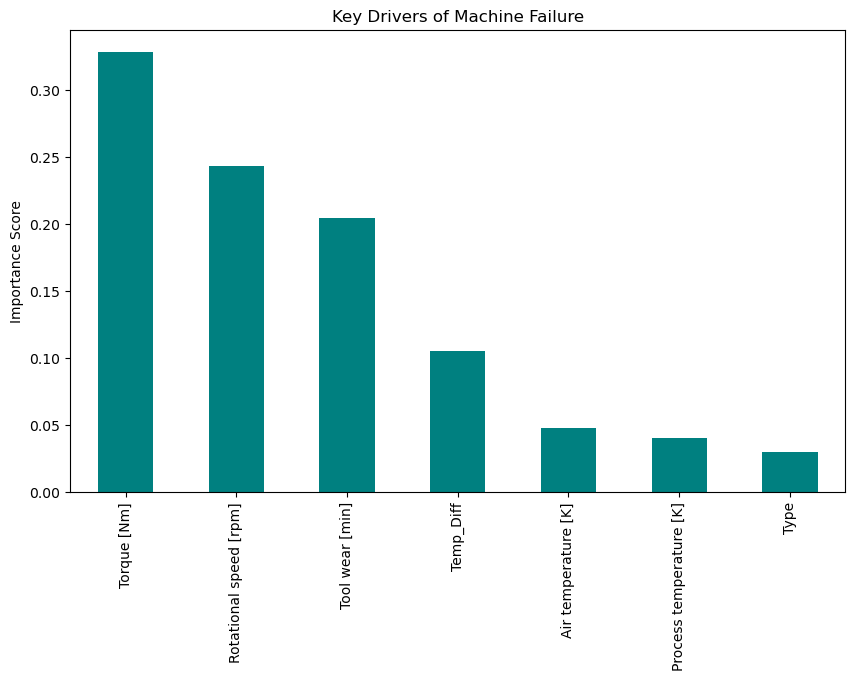

In [78]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.plot(kind='bar', color='teal')
plt.title('Key Drivers of Machine Failure')
plt.ylabel('Importance Score')
plt.savefig('feature_importance.png')

In [79]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test_scaled)[:,1]
roc_score = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", roc_score)


ROC AUC Score: 0.9798174704664474


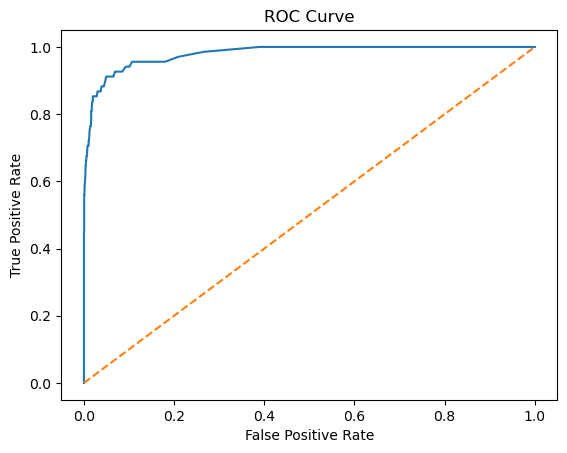

In [80]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [88]:
# # Select only numerical columns
# num_cols = X.select_dtypes(include=np.number).columns

# plt.figure(figsize=(15,8))
# sns.boxplot(data=df_clean[num_cols])
# plt.xticks(rotation=90)
# plt.title("Boxplot for Outlier Detection")
# plt.show()


In [87]:
# sns.boxplot(x=df_clean['Target'], y=df_clean['Rotational speed [rpm]'])
# plt.title("RPM vs Failure")
# plt.show()
# #

In [86]:
# Q1 = df_clean['Rotational speed [rpm]'].quantile(0.25)
# Q3 = df_clean['Rotational speed [rpm]'].quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# df_no_outliers = df_clean[
#     (df_clean['Rotational speed [rpm]'] >= lower) &
#     (df_clean['Rotational speed [rpm]'] <= upper)
# ]

# print("Original shape:", df_clean.shape)
# print("After removing RPM outliers:", df_no_outliers.shape)
